# Giai doan 3 – ALS Token Recommendation

Notebook nay xu ly phan ALS trong Giai doan 3 cua pipeline:

    Input  : Du lieu da qua Stage 2 (Data Cleaning) + PageRank Score tu teammate
    Output : ALS Model + Top-N Token recommendations cho tung vi

Luong du lieu:

    [Cleaned Parquet - Stage 2]  →  3 thang gan nhat (Sliding Window tu nhien)
           |
    [Load PageRank Score tu teammate]
           |
    [Tinh Ultimate_Confidence = log(tx+1) × (1 + pagerank_score)]
           |
    [ALS Training]
           |
    [Hybrid Router: Vi cu -> ALS | Vi moi -> Safe/Trending]




## Cell 1 – Khoi tao Spark Session

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("ALS_Token_Recommendation") \
    .config("spark.sql.broadcastTimeout", "3600") \
    .getOrCreate()

# Du lieu nhan vao la output cua Stage 2 (da qua Data Cleaning & Labeling)
# Stage 2 da:
#   - Loc bot bang left_anti join voi contracts (chi giu EOA)
#   - Chuan hoa gia tri theo decimals
#   - Ap dung log(x+1) xu ly outliers
#   - Luu Delta Lake dinh dang .parquet
df = spark.read.parquet("/content/part-00000-c98b63a6-c8ca-45bb-a526-b82103965c18-c000.snappy.parquet")

df.printSchema()
df.show(5)

root
 |-- user_id: integer (nullable = true)
 |-- token_id: integer (nullable = true)
 |-- total_tx: long (nullable = true)
 |-- num_holders: long (nullable = true)

+-------+--------+--------+-----------+
|user_id|token_id|total_tx|num_holders|
+-------+--------+--------+-----------+
|      6|   15798|      33|        541|
|      8|   15798|      11|        541|
|      9|   15798|      21|        541|
|     10|   15798|      33|        541|
|     20|   15798|     164|        541|
+-------+--------+--------+-----------+
only showing top 5 rows


## Cell 2 – Kiem tra Sparsity (EDA – tham chieu tu Giai doan 1)

Buoc nay co the da duoc lam o Stage 1. Giu lai de xac nhan nguong truoc khi train ALS.

In [ ]:
num_users  = df.select("user_id").distinct().count()
num_tokens = df.select("token_id").distinct().count()
actual     = df.count()
sparsity   = (1.0 - actual / (num_users * num_tokens)) * 100

print("THONG KE MA TRAN")
print(f"  So Vi (Users)      : {num_users:,}")
print(f"  So Tokens          : {num_tokens:,}")
print(f"  Tuong tac thuc te  : {actual:,}")
print(f"  Do thua (Sparsity) : {sparsity:.4f}%")

THONG KE MA TRAN
  So Vi (Users)      : 232,502
  So Tokens          : 106
  Tuong tac thuc te  : 242,956
  Do thua (Sparsity) : 99.0142%


## Cell 3 – Phan phoi du lieu (tham chieu tu Giai doan 1)

Kiem tra Power-law: 1% vi co chiem da so giao dich khong?

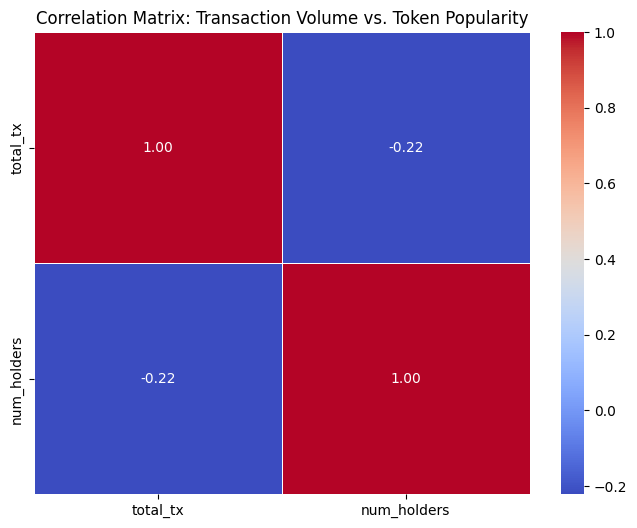

In [ ]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ma tran tuong quan giua total_tx va num_holders
columns_to_corr = ["total_tx", "num_holders"]
assembler = VectorAssembler(inputCols=columns_to_corr, outputCol="features")
df_vector = assembler.transform(df).select("features")
matrix    = Correlation.corr(df_vector, "features").collect()[0][0]
corr_df   = pd.DataFrame(matrix.toArray(), columns=columns_to_corr, index=columns_to_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Transaction Volume vs. Token Popularity")
plt.show()

---
# TANG 1 – Feature Engineering: Xay dung Ultimate_Confidence

Cong thuc (da gian luoc Time-Decay):

    Ultimate_Confidence = log(total_tx + 1)  ×  (1 + PageRank_Score)

| Thanh phan | Y nghia |
|---|---|
| `log(total_tx + 1)` | Nguoi giao dich nhieu → diem tang, log xu ly outlier |
| `(1 + pagerank_score)` | Vi uy tin mang nhieu anh huong → diem nhan len |

**Time-Decay = 1.0 (hang so) vi du lieu chi gom 3 thang:**
- Sliding Window 90 ngay da dam bao moi giao dich la "hien tai"
- Them decay factor se gay nhieu khong can thiet


## Cell 4 – Load PageRank Score tu teammate

**Schema thuc te cua teammate:** `id` (integer) | `pagerank` (double)  
- `id` → tuong ung voi `user_id_int` sinh ra boi StringIndexer o Cell 7  
- `pagerank` → diem PageRank thu (se normalize ve [0, 1])  

Pipeline xu ly:  
1. Giai nen ZIP neu can  
2. Doc toan bo thu muc parquet  
3. Rename cot cho khop voi pipeline  
4. Normalize ve [0, 1]  

> **Luu y:** Join voi bang chinh duoc thuc hien o Cell 7 (sau khi co `user_id_int` tu StringIndexer).

In [ ]:
# ================================================================
# PAGERANK – Du lieu thuc te tu teammate
# Schema goc: id (integer) | pagerank (double)
#
# QUAN TRONG: 'id' trong PageRank = raw user_id (integer) trong df chinh
# KHONG phai user_id_int (StringIndexer index) !!!
# Join phai duoc thuc hien TRUOC StringIndexer (Cell 6)
# ================================================================
import os, zipfile

# ----------------------------------------------------------------
# BUOC 1: Giai nen ZIP (neu chay lan dau)
# ----------------------------------------------------------------
ZIP_PATH      = "/content/full_pagerank_results_parquet.zip"
PAGERANK_DIR  = "/content/full_pagerank_results_parquet"
PAGERANK_PATH = PAGERANK_DIR

if not os.path.exists(PAGERANK_DIR):
    print("Dang giai nen ZIP PageRank...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall("/content/")
    print(f"Giai nen xong -> {PAGERANK_DIR}")
else:
    print(f"Thu muc da ton tai: {PAGERANK_DIR}")

# ----------------------------------------------------------------
# BUOC 2: Doc va rename dung cot
#   id       -> user_id   (= raw user_id integer trong df chinh)
#   pagerank -> pagerank_score
# ----------------------------------------------------------------
df_pagerank_raw = spark.read.parquet(PAGERANK_PATH)

print("\n[Schema goc tu teammate]")
df_pagerank_raw.printSchema()
df_pagerank_raw.show(5)

df_pagerank = df_pagerank_raw.select(
    F.col("id").cast("integer").alias("user_id"),   # join voi raw user_id, KHONG phai StringIndexer index
    F.col("pagerank").alias("pagerank_score")
)

# ----------------------------------------------------------------
# BUOC 3: Normalize pagerank_score ve [0, 1] (Min-Max)
# ----------------------------------------------------------------
stats  = df_pagerank.agg(
    F.max("pagerank_score").alias("max_pr"),
    F.min("pagerank_score").alias("min_pr")
).collect()[0]
max_pr, min_pr = stats["max_pr"], stats["min_pr"]

df_pagerank = df_pagerank.withColumn(
    "pagerank_score",
    (F.col("pagerank_score") - min_pr) / (max_pr - min_pr)
)

df_pagerank.cache()

total_pr = df_pagerank.count()
print(f"\n[PageRank da load xong] {total_pr:,} records")
print(f"  PageRank goc  : min={min_pr:.6e}  max={max_pr:.6e}")
print("  Sau normalize : min=0.0  max=1.0")
print("\n[Top 10 vi uy tin nhat]")
df_pagerank.orderBy(F.col("pagerank_score").desc()).show(10)
print("PageRank san sang – se join vao df chinh theo raw user_id o Cell 6.")


Dang giai nen ZIP PageRank...
Giai nen xong -> /content/full_pagerank_results_parquet

[Schema goc tu teammate]
root
 |-- id: integer (nullable = true)
 |-- pagerank: double (nullable = true)

+---+------------------+
| id|          pagerank|
+---+------------------+
|  9|0.1514655172413793|
| 19|0.3088533560518058|
| 29|0.6969485634871506|
| 39|0.1514655172413793|
| 49|0.1514655172413793|
+---+------------------+
only showing top 5 rows

[PageRank da load xong] 4,836,441 records
  PageRank goc  : min=1.500000e-01  max=9.557126e+04
  Sau normalize : min=0.0  max=1.0

[Top 10 vi uy tin nhat]
+-------+-------------------+
|user_id|     pagerank_score|
+-------+-------------------+
| 784248|                1.0|
| 516499| 0.4241258346257267|
| 480915|0.42368197226501414|
|3218106|0.38264323597309946|
|2867319|    0.3783863366783|
|1634001| 0.3431443669766931|
|4184876|0.22769276622358436|
|4000287|0.20612042874120615|
|4682412| 0.1850256268406785|
| 864043|0.16287073719303613|
+-------+---

## Cell 5 – [DA BO] Time-Decay Score

> **Ly do bo:** Du lieu chi gom 3 thang gan nhat (Sliding Window tu nhien).
> Khoang cach thoi gian giua giao dich cu nhat va moi nhat la ≈ 90 ngay –
> qua nho de tao ra Historical Bias dang ke.
> Time-Decay duoc set = 1.0 (hang so), tuong duong viec bo han.


In [ ]:
# [DA BO] Time-Decay = hang so 1.0 vi du lieu chi gom 3 thang (Sliding Window tu nhien).
# Cell 6 se join thang tu df goc ma khong qua buoc nay.
# Giu cell nay de ghi nhan quyet dinh thiet ke.

print("[THIET KE] Time-Decay da bi loai khoi pipeline.")
print("  Ly do: Du lieu chi gom 3 thang ≈ 90 ngay (Sliding Window tu nhien).")
print("  Moi giao dich deu co do 'moi me' tuong duong → khong can discount.")
print("  Cong thuc: Ultimate_Confidence = log(tx+1) × (1 + pagerank_score)")


[THIET KE] Time-Decay da bi loai khoi pipeline.
  Ly do: Du lieu chi gom 3 thang ≈ 90 ngay (Sliding Window tu nhien).
  Moi giao dich deu co do 'moi me' tuong duong → khong can discount.
  Cong thuc: Ultimate_Confidence = log(tx+1) × (1 + pagerank_score)


## Cell 6 – Join PageRank & Tinh Ultimate_Confidence

**Ly do join PageRank o day (truoc StringIndexer):**
- `pagerank.id` = raw `user_id` integer trong df chinh
- StringIndexer tao `user_id_int` la index tan so — KHONG lien quan den PageRank id
- Join sau StringIndexer se map sai user → confidence sai

Cong thuc day du (da gian luoc time_decay = 1.0):

```
Ultimate_Confidence = log(total_tx + 1)  ×  (1 + pagerank_score)
```


In [ ]:
# ----------------------------------------------------------------
# BUOC 1: Join PageRank vao df chinh theo raw user_id
# ----------------------------------------------------------------
df_with_pagerank = df.join(          # dung thang df goc (khong qua time_decay)
    df_pagerank,
    on="user_id",   # raw user_id integer – join DUNG !
    how="left"
).fillna({"pagerank_score": 0.0})

# Kiem tra coverage
total_u = df_with_pagerank.select("user_id").distinct().count()
with_pr  = df_with_pagerank.filter(F.col("pagerank_score") > 0).select("user_id").distinct().count()
print(f"[PageRank Coverage] {with_pr:,} / {total_u:,} user co diem PageRank ({with_pr/total_u*100:.1f}%)")

# ----------------------------------------------------------------
# BUOC 2: Tinh Ultimate_Confidence
#   = log(total_tx + 1)  x  (1 + pagerank_score)
# ----------------------------------------------------------------
df_final = df_with_pagerank.withColumn(
    "ultimate_confidence",
    F.log1p(F.col("total_tx"))          # Thanh phan 1: Volume (log scale)
    * (1.0 + F.col("pagerank_score"))   # Thanh phan 2: Uy tin vi (PageRank)
)

print("\nTANG 1 HOAN THANH – Ultimate_Confidence")
df_final.select(
    "user_id", "token_id", "total_tx",
    "pagerank_score", "ultimate_confidence"
).orderBy(F.col("ultimate_confidence").desc()).show(10)

df_final.select("ultimate_confidence").describe().show()


[PageRank Coverage] 232,501 / 232,502 user co diem PageRank (100.0%)

TANG 1 HOAN THANH – Ultimate_Confidence
+-------+--------+--------+--------------------+-------------------+
|user_id|token_id|total_tx|      pagerank_score|ultimate_confidence|
+-------+--------+--------+--------------------+-------------------+
|1597160|  148306|    4685|0.022325349115461336|   8.64103594027913|
| 794083|  148306|    4721|0.011280862076336216|  8.555423672255715|
|2135823|  148306|    4931|0.004691326935184...|  8.543392562240886|
|1902324|  148306|    4669| 0.00929135181346889|  8.527416186336819|
|4773778|  148306|    4853|0.002928728490190...|  8.512416140344623|
|4773778|   55204|    4853|0.002928728490190...|  8.512416140344623|
|4773778|   61502|    4853|0.002928728490190...|  8.512416140344623|
|3849631|  148306|    4233|0.018939714703128923|   8.50906616164357|
|3893683|   23413|    4589|0.009137601169178956|  8.508680223657874|
|3893683|  125192|    4589|0.009137601169178956|  8.5086802236

---
# TANG 2 – ALS Matrix Factorization

Dau vao da qua Feature Engineering -> ALS hoc tren du lieu chat luong cao.

## Cell 7 – Encode ID và Train/Test Split

StringIndexer map `user_id` / `token_id` sang integer index cho ALS.
Train trên **toàn bộ 242,956 tương tác** — không filter bỏ user nào.

Sparsity 99% là đặc điểm tự nhiên của dữ liệu blockchain (phần lớn ví
chỉ giao dịch 1 token). Hybrid Router đã xử lý điều này:
ALS phục vụ users có lịch sử, Trending/Safe phục vụ phần còn lại.


In [ ]:
from pyspark.ml.recommendation import ALS
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline

# ----------------------------------------------------------------
# Bật checkpoint để cắt lineage – bắt buộc với pipeline dài
# Nếu không có bước này ALS.fit() sẽ StackOverflowError
# ----------------------------------------------------------------
spark.sparkContext.setCheckpointDir("/content/spark_checkpoints")

# StringIndexer
user_indexer  = StringIndexer(inputCol="user_id",  outputCol="user_id_int",  handleInvalid="keep")
token_indexer = StringIndexer(inputCol="token_id", outputCol="token_id_int", handleInvalid="keep")

pipeline   = Pipeline(stages=[user_indexer, token_indexer])
df_indexed = pipeline.fit(df_final).transform(df_final) \
    .withColumn("user_id_int",  F.col("user_id_int").cast("integer")) \
    .withColumn("token_id_int", F.col("token_id_int").cast("integer"))

# Checkpoint + cache: cắt đứt DAG lineage dài trước khi split
df_indexed = df_indexed.checkpoint()
df_indexed.cache()

total_interactions = df_indexed.count()
total_users        = df_indexed.select("user_id_int").distinct().count()
total_tokens       = df_indexed.select("token_id_int").distinct().count()
print(f"[Train data] {total_interactions:,} interactions | {total_users:,} users | {total_tokens} tokens")
print(f"  Avg: {total_interactions/total_users:.2f} interactions/user")
print(f"  Checkpoint xong – lineage da duoc cat")

df_indexed.select("ultimate_confidence").describe().show()

# Split sau khi đã checkpoint – lineage sạch
train_df, test_df = df_indexed.randomSplit([0.8, 0.2], seed=42)

# Checkpoint cả train/test để ALS.fit không đi ngược lineage
train_df = train_df.checkpoint()
test_df  = test_df.checkpoint()
train_df.cache()
test_df.cache()

print(f"Train: {train_df.count():,} rows")
print(f"Test : {test_df.count():,} rows")


[Train data] 242,956 interactions | 232,502 users | 106 tokens
  Avg: 1.04 interactions/user
  Checkpoint xong – lineage da duoc cat
+-------+-------------------+
|summary|ultimate_confidence|
+-------+-------------------+
|  count|             242956|
|   mean| 3.2184315720585044|
| stddev| 0.8851726356177859|
|    min|  2.397895272846411|
|    max|   8.64103594027913|
+-------+-------------------+

Train: 194,339 rows
Test : 48,617 rows


## Cell 8 – Train ALS

Model được chọn theo **NDCG@10**.
Grid search 4 bộ params, mỗi bộ train độc lập từ `train_df` đã checkpoint.

> **Lưu ý kỹ thuật:** `train_df` đã được checkpoint ở Cell 7 nên
> mỗi vòng `als.fit()` sẽ đọc từ file checkpoint, tránh StackOverflowError
> do lineage quá dài.


In [ ]:
import math
from pyspark.sql import Window

def ndcg_at_k(model, test_df, K=10):
    # Tất cả users trong test – không filter, dù chỉ có 1 token cũng đánh giá
    test_users_eval = test_df.select("user_id_int").distinct()
    n = test_users_eval.count()
    if n == 0:
        return 0.0, 0

    ground_truth = test_df.groupBy("user_id_int").agg(
        F.collect_set("token_id_int").alias("actual_tokens"))

    recs = model.recommendForUserSubset(test_users_eval, K)
    recs_flat = recs.select("user_id_int", F.explode("recommendations").alias("rec")) \
        .select("user_id_int",
                F.col("rec.token_id_int").alias("rec_token"),
                F.col("rec.rating").alias("rec_score"))
    w = Window.partitionBy("user_id_int").orderBy(F.col("rec_score").desc())
    eval_pdf = recs_flat.withColumn("rank", F.rank().over(w)) \
        .join(ground_truth, on="user_id_int") \
        .toPandas()

    ndcg_list = []
    for _, grp in eval_pdf.groupby("user_id_int"):
        actual = set(grp["actual_tokens"].iloc[0])
        top_k  = grp.sort_values("rank").head(K)
        hits   = [1 if r in actual else 0 for r in top_k["rec_token"]]
        n_rel  = len(actual)
        dcg    = sum(h/math.log2(i+2) for i,h in enumerate(hits))
        ideal  = [1]*min(n_rel,K)+[0]*(K-min(n_rel,K))
        idcg   = sum(h/math.log2(i+2) for i,h in enumerate(ideal))
        ndcg_list.append(dcg/idcg if idcg>0 else 0)

    return round(sum(ndcg_list)/len(ndcg_list), 4), len(ndcg_list)

param_grid = [
    {"rank": 30, "regParam": 0.1,  "alpha": 15.0, "label": "rank=30 reg=0.10 alpha=15"},
    {"rank": 50, "regParam": 0.1,  "alpha": 15.0, "label": "rank=50 reg=0.10 alpha=15"},
    {"rank": 50, "regParam": 0.05, "alpha": 20.0, "label": "rank=50 reg=0.05 alpha=20"},
    {"rank": 50, "regParam": 0.01, "alpha": 25.0, "label": "rank=50 reg=0.01 alpha=25"},
]

results    = []
best_ndcg  = -1.0
best_model = None
best_label = ""

for p in param_grid:
    print(f"\nDang train: {p['label']} ...")
    _als = ALS(
        rank=p["rank"], maxIter=20, regParam=p["regParam"], alpha=p["alpha"],
        implicitPrefs=True, userCol="user_id_int", itemCol="token_id_int",
        ratingCol="ultimate_confidence", coldStartStrategy="drop",
        nonnegative=True, seed=42,
    )
    _model      = _als.fit(train_df)
    _ndcg, n_ev = ndcg_at_k(_model, test_df, K=10)
    print(f"  -> NDCG@10 = {_ndcg:.4f}  ({n_ev:,} users)")
    results.append({"label": p["label"], "ndcg": _ndcg})
    if _ndcg > best_ndcg:
        best_ndcg, best_model, best_label = _ndcg, _model, p["label"]

als_model = best_model
print(f"\nBest: {best_label}  (NDCG@10 = {best_ndcg:.4f})")
print("\n=== BANG SO SANH ===")
for r in sorted(results, key=lambda x: x["ndcg"], reverse=True):
    m = " <-- BEST" if r["label"] == best_label else ""
    print(f"  {r['label']:40s}  NDCG@10={r['ndcg']:.4f}{m}")



Dang train: rank=30 reg=0.10 alpha=15 ...
  -> NDCG@10 = 0.0835  (2,002 users)

Dang train: rank=50 reg=0.10 alpha=15 ...
  -> NDCG@10 = 0.0747  (2,002 users)

Dang train: rank=50 reg=0.05 alpha=20 ...
  -> NDCG@10 = 0.0711  (2,002 users)

Dang train: rank=50 reg=0.01 alpha=25 ...
  -> NDCG@10 = 0.3334  (2,002 users)

Best: rank=50 reg=0.01 alpha=25  (NDCG@10 = 0.3334)

=== BANG SO SANH ===
  rank=50 reg=0.01 alpha=25                 NDCG@10=0.3334 <-- BEST
  rank=30 reg=0.10 alpha=15                 NDCG@10=0.0835
  rank=50 reg=0.10 alpha=15                 NDCG@10=0.0747
  rank=50 reg=0.05 alpha=20                 NDCG@10=0.0711


## Cell 9 – Đánh giá mô hình

Đánh giá trên **toàn bộ users trong test set** — không filter bỏ user nào.
Với user chỉ có 1 token trong test thì token đó chính là ground truth.

Chỉ dùng **ranking metrics** — RMSE/R²/MAE không có ý nghĩa với implicit ALS.


[Evaluation] Toan bo 47,738 users trong test set

TOM TAT DANH GIA (RANKING METRICS – TOAN BO TEST USERS)
  [K=5] (tren 2,002 users)
    Precision : 0.1077  |  Recall  : 0.4956
    NDCG      : 0.2736  |  HitRate : 0.5250
  [K=10] (tren 2,002 users)
    Precision : 0.0745  |  Recall  : 0.6679
    NDCG      : 0.3334  |  HitRate : 0.7083
  [K=20] (tren 2,002 users)
    Precision : 0.0457  |  Recall  : 0.7786
    NDCG      : 0.3639  |  HitRate : 0.8262
  Coverage : 100.0%  (106/106 tokens)


/tmp/ipykernel_16684/1317985975.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


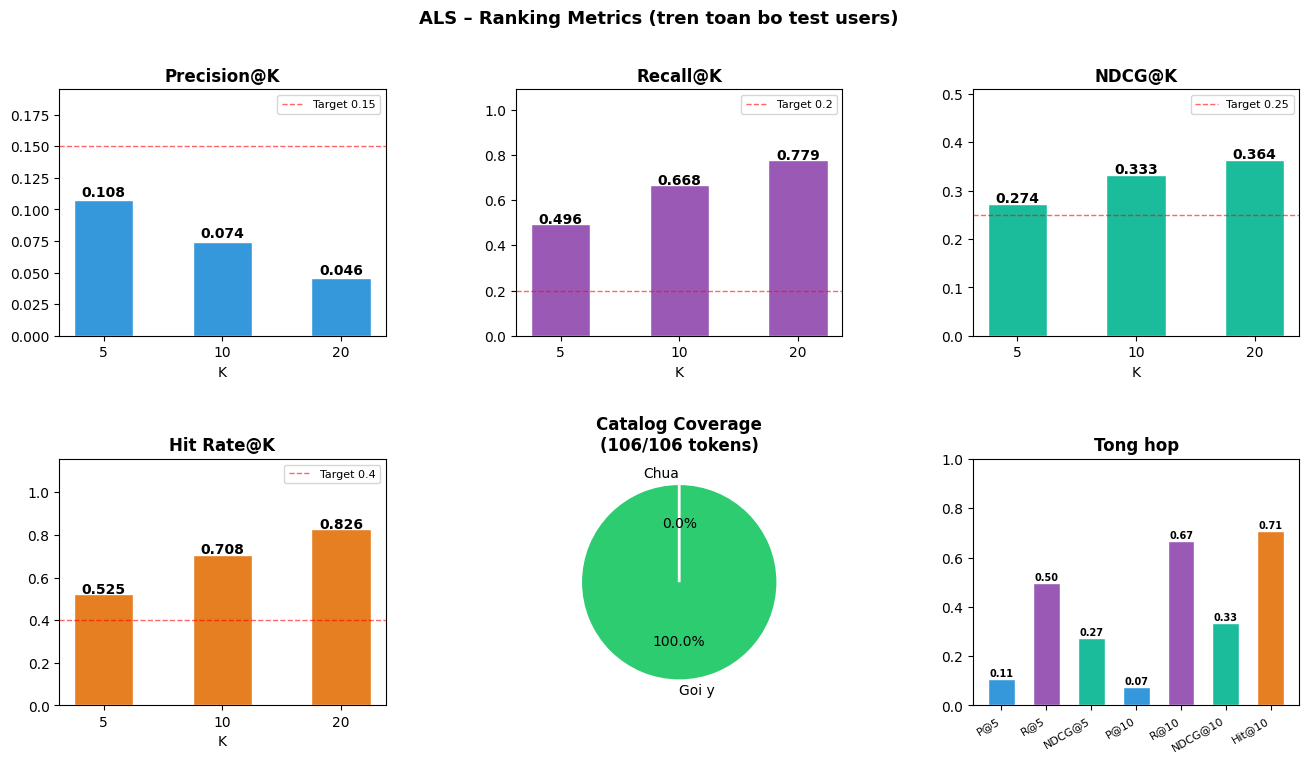

Saved: /content/als_evaluation_v4.png


In [ ]:
import math, matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
from pyspark.sql import Window

# Toàn bộ users trong test – không filter
test_users_eval = test_df.select("user_id_int").distinct()
n_eval = test_users_eval.count()
print(f"[Evaluation] Toan bo {n_eval:,} users trong test set")

ground_truth = test_df.groupBy("user_id_int").agg(
    F.collect_set("token_id_int").alias("actual_tokens"))

def ranking_metrics(model, gt_df, users_df, K):
    recs = model.recommendForUserSubset(users_df, K)
    recs_flat = recs.select("user_id_int", F.explode("recommendations").alias("rec")) \
        .select("user_id_int",
                F.col("rec.token_id_int").alias("rec_token"),
                F.col("rec.rating").alias("rec_score"))
    w   = Window.partitionBy("user_id_int").orderBy(F.col("rec_score").desc())
    pdf = recs_flat.withColumn("rank", F.rank().over(w)) \
        .join(gt_df, on="user_id_int") \
        .toPandas()

    P, R, N, H = [], [], [], []
    for _, g in pdf.groupby("user_id_int"):
        actual = set(g["actual_tokens"].iloc[0])
        top_k  = g.sort_values("rank").head(K)
        hits   = [1 if r in actual else 0 for r in top_k["rec_token"]]
        n_rel  = len(actual)
        prec   = sum(hits)/K
        rec    = sum(hits)/n_rel if n_rel>0 else 0
        dcg    = sum(h/math.log2(i+2) for i,h in enumerate(hits))
        ideal  = [1]*min(n_rel,K)+[0]*(K-min(n_rel,K))
        idcg   = sum(h/math.log2(i+2) for i,h in enumerate(ideal))
        P.append(prec); R.append(rec)
        N.append(dcg/idcg if idcg>0 else 0)
        H.append(1 if sum(hits)>0 else 0)
    n = len(P)
    return {f"P@{K}":    round(sum(P)/n, 4),
            f"R@{K}":    round(sum(R)/n, 4),
            f"NDCG@{K}": round(sum(N)/n, 4),
            f"Hit@{K}":  round(sum(H)/n, 4),
            "n": n}

m5  = ranking_metrics(als_model, ground_truth, test_users_eval, 5)
m10 = ranking_metrics(als_model, ground_truth, test_users_eval, 10)
m20 = ranking_metrics(als_model, ground_truth, test_users_eval, 20)

all_tokens_n = df_indexed.select("token_id_int").distinct().count()
covered      = als_model.recommendForUserSubset(test_users_eval, 10) \
    .select(F.explode("recommendations").alias("r")) \
    .select(F.col("r.token_id_int")).distinct().count()
coverage = covered / all_tokens_n * 100

print("\n" + "="*55)
print("TOM TAT DANH GIA (RANKING METRICS – TOAN BO TEST USERS)")
print("="*55)
for lbl, m, k in [("K=5",m5,5),("K=10",m10,10),("K=20",m20,20)]:
    print(f"  [{lbl}] (tren {m['n']:,} users)")
    print(f"    Precision : {m[f'P@{k}']:.4f}  |  Recall  : {m[f'R@{k}']:.4f}")
    print(f"    NDCG      : {m[f'NDCG@{k}']:.4f}  |  HitRate : {m[f'Hit@{k}']:.4f}")
print(f"  Coverage : {coverage:.1f}%  ({covered}/{all_tokens_n} tokens)")
print("="*55)

# ── Visualization ─────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 8))
fig.suptitle("ALS – Ranking Metrics (tren toan bo test users)", fontsize=13, fontweight="bold")
gs  = gridspec.GridSpec(2, 3, hspace=0.5, wspace=0.4)
clr = ["#3498db","#9b59b6","#1abc9c","#e67e22"]
Ks  = ["5","10","20"]

specs = [
    ("P",    [m5["P@5"],    m10["P@10"],    m20["P@20"]],    0.15, "Precision@K"),
    ("R",    [m5["R@5"],    m10["R@10"],    m20["R@20"]],    0.20, "Recall@K"),
    ("NDCG", [m5["NDCG@5"], m10["NDCG@10"], m20["NDCG@20"]], 0.25, "NDCG@K"),
    ("Hit",  [m5["Hit@5"],  m10["Hit@10"],  m20["Hit@20"]],  0.40, "Hit Rate@K"),
]
for idx, (key, vals, tgt, title) in enumerate(specs):
    ax = fig.add_subplot(gs[idx//3, idx%3])
    bars = ax.bar(Ks, vals, color=clr[idx], width=0.5, edgecolor="white")
    ax.axhline(y=tgt, color="red", linestyle="--", alpha=0.6, linewidth=1, label=f"Target {tgt}")
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2, v+.003, f"{v:.3f}",
                ha="center", fontsize=10, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, max(max(vals)*1.4, tgt*1.3))
    ax.set_xlabel("K"); ax.legend(fontsize=8)

ax5 = fig.add_subplot(gs[1,1])
ax5.pie([coverage,100-coverage], labels=["Goi y","Chua"],
        colors=["#2ecc71","#ecf0f1"], autopct="%1.1f%%", startangle=90,
        wedgeprops={"edgecolor":"white","linewidth":2})
ax5.set_title(f"Catalog Coverage\n({covered}/{all_tokens_n} tokens)", fontweight="bold")

ax6 = fig.add_subplot(gs[1,2])
names = ["P@5","R@5","NDCG@5","P@10","R@10","NDCG@10","Hit@10"]
vals6 = [m5["P@5"],m5["R@5"],m5["NDCG@5"],
         m10["P@10"],m10["R@10"],m10["NDCG@10"],m10["Hit@10"]]
bars6 = ax6.bar(range(7), vals6,
                color=["#3498db","#9b59b6","#1abc9c"]*2+["#e67e22"],
                width=0.6, edgecolor="white")
ax6.set_xticks(range(7))
ax6.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
ax6.set_ylim(0,1.0); ax6.set_title("Tong hop", fontweight="bold")
for b,v in zip(bars6,vals6):
    ax6.text(b.get_x()+b.get_width()/2, v+.01, f"{v:.2f}",
             ha="center", fontsize=7, fontweight="bold")

plt.tight_layout()
plt.savefig("/content/als_evaluation_v4.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/als_evaluation_v4.png")


---
# TANG 3 – Hybrid Router

Cong logic phan phoi ket qua den tung loai nguoi dung.

## Cell 10 – Chuan bi Cold-Start Catalog

In [ ]:
# Safe Tokens: Token duoc thi truong chap nhan (nhieu holder, volume cao)
df_safe_tokens = df_indexed \
    .filter(F.col("num_holders") > 1000) \
    .groupBy("token_id_int", "token_id") \
    .agg(
        F.max("num_holders").alias("num_holders"),
        F.sum("total_tx").alias("total_volume")
    ) \
    .withColumn(
        "safety_score",
        F.log1p(F.col("num_holders")) * F.log1p(F.col("total_volume"))
    ) \
    .orderBy(F.col("safety_score").desc())

# Trending Tokens: Token dang len xu huong, chua mainstream
# Logic: tx/holder ratio cao = duoc giao dich nhieu so voi so luong holder
df_trending_tokens = df_indexed \
    .filter(
        (F.col("num_holders") >= 10) &
        (F.col("num_holders") < 5000)
    ) \
    .groupBy("token_id_int", "token_id") \
    .agg(
        F.max("num_holders").alias("num_holders"),
        F.sum("total_tx").alias("total_volume")
    ) \
    .withColumn(
        "momentum_score",
        F.col("total_volume") / F.col("num_holders")
    ) \
    .orderBy(F.col("momentum_score").desc())

df_safe_tokens.cache()
df_trending_tokens.cache()

print("Cold-Start Catalog da san sang.")
print("\nTOP 5 SAFE TOKENS:")
df_safe_tokens.select("token_id", "num_holders", "total_volume", "safety_score").show(5)
print("\nTOP 5 TRENDING TOKENS:")
df_trending_tokens.select("token_id", "num_holders", "total_volume", "momentum_score").show(5)

Cold-Start Catalog da san sang.

TOP 5 SAFE TOKENS:
+--------+-----------+------------+------------------+
|token_id|num_holders|total_volume|      safety_score|
+--------+-----------+------------+------------------+
|  148306|    1404064|     9089124|226.79786203155783|
|  130121|      33797|      529931|137.44836358371268|
|   55204|      27330|      276762|128.01305021901294|
|   23413|      13415|      217680|116.81412859349756|
|   50323|       5646|       86009| 98.15684185892333|
+--------+-----------+------------+------------------+
only showing top 5 rows

TOP 5 TRENDING TOKENS:
+--------+-----------+------------+------------------+
|token_id|num_holders|total_volume|    momentum_score|
+--------+-----------+------------+------------------+
|    5931|         65|       19840| 305.2307692307692|
|  160295|        108|       31990| 296.2037037037037|
|   47835|        187|       53793| 287.6631016042781|
|  115796|         65|       17859|274.75384615384615|
|  171472|         6

## Cell 11 – Ham Hybrid Router chinh

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.utils import AnalysisException

def recommend_for_user(user_id, model, df_history, df_safe, df_trending, top_n=10, risk_mode="safe"):
    try:
        # KỸ THUẬT ÉP KIỂU RÕ RÀNG: Bắt Spark phải coi cả 2 vế là văn bản (String)
        # Hàm F.lit() giúp định nghĩa "0x..." là một hằng số chuỗi tuyệt đối
        user_records = df_history.filter(
            F.col("user_id").cast("string") == F.lit(user_id).cast("string")
        ).select("user_id_int").limit(1).collect()

        if len(user_records) > 0:
            print(f"[HỆ THỐNG] Ví {user_id} là ví CŨ. Đang gọi mô hình ALS...")
            mapped_user_int = user_records[0]["user_id_int"]
            user_df = spark.createDataFrame([(mapped_user_int,)], ["user_id_int"])
            raw_recs = model.recommendForUserSubset(user_df, top_n)

            result = raw_recs.select(F.explode("recommendations").alias("rec")) \
                             .select(F.col("rec.token_id_int").alias("token_id_int"),
                                     F.col("rec.rating").alias("predicted_score"))
            return result
        else:
            # Nếu không tìm thấy, chủ động tạo lỗi để nhảy xuống phần except
            raise ValueError("New User")

    except Exception as e:
        # Bất kể là lỗi không có cột user_id, lỗi ép kiểu, hay không tìm thấy ví...
        # Hệ thống sẽ TỰ ĐỘNG fallback về luồng an toàn cho ví mới mà không bị crash
        print(f"[HỆ THỐNG] Ví {user_id} là ví MỚI (Cold-Start) hoặc ẩn danh. Kích hoạt Hybrid Fallback...")

        if risk_mode == "safe":
            print(">> Khẩu vị: AN TOÀN (Mass Adoption)")
            return df_safe.limit(top_n)
        else:
            print(">> Khẩu vị: DARING (Trending / Degen)")
            return df_trending.limit(top_n)

## Cell 12 – Chay thu he thong

In [ ]:
print("TEST 1: Vi cu (co lich su giao dich)")
sample_old_user = df_indexed.select("user_id").first()[0]

recommend_for_user(
    user_id    = sample_old_user,
    model      = als_model,
    df_history = df_indexed,
    df_safe    = df_safe_tokens,
    df_trending= df_trending_tokens,
    top_n      = 10,
    risk_mode  = "safe"
)

TEST 1: Vi cu (co lich su giao dich)
[HỆ THỐNG] Ví 6 là ví CŨ. Đang gọi mô hình ALS...


DataFrame[token_id_int: int, predicted_score: float]

In [ ]:
# Sẽ in ra: "Ví ... là ví MỚI TOANH... Khẩu vị: AN TOÀN"
test_1 = recommend_for_user(
    user_id    = "0xNEW_WALLET_ADDRESS",
    model      = als_model,
    df_history = df_indexed,
    df_safe    = df_safe_tokens,
    df_trending= df_trending_tokens,
    top_n      = 10,
    risk_mode  = "safe"
)
test_1.show(truncate=False)

[HỆ THỐNG] Ví 0xNEW_WALLET_ADDRESS là ví MỚI (Cold-Start) hoặc ẩn danh. Kích hoạt Hybrid Fallback...
>> Khẩu vị: AN TOÀN (Mass Adoption)
+------------+--------+-----------+------------+------------------+
|token_id_int|token_id|num_holders|total_volume|safety_score      |
+------------+--------+-----------+------------+------------------+
|0           |148306  |1404064    |9089124     |226.79786203155783|
|1           |130121  |33797      |529931      |137.44836358371268|
|3           |55204   |27330      |276762      |128.01305021901294|
|2           |23413   |13415      |217680      |116.81412859349756|
|4           |50323   |5646       |86009       |98.15684185892333 |
|15          |123615  |3543       |63437       |90.37567429376756 |
|5           |61502   |2023       |124344      |89.30471426599176 |
|11          |109069  |2083       |85066       |86.74633209104972 |
|6           |9173    |1440       |105312      |84.11107683148346 |
|7           |10403   |1209       |94436       

In [ ]:
print("TEST 3: Vi moi – Khau vi MAO HIEM")
recommend_for_user(
    user_id    = "0xNEW_WALLET_ADDRESS",
    model      = als_model,
    df_history = df_indexed,
    df_safe    = df_safe_tokens,
    df_trending= df_trending_tokens,
    top_n      = 10,
    risk_mode  = "daring"
)

TEST 3: Vi moi – Khau vi MAO HIEM
[HỆ THỐNG] Ví 0xNEW_WALLET_ADDRESS là ví MỚI (Cold-Start) hoặc ẩn danh. Kích hoạt Hybrid Fallback...
>> Khẩu vị: DARING (Trending / Degen)


DataFrame[token_id_int: int, token_id: int, num_holders: bigint, total_volume: bigint, momentum_score: double]

## Cell 13 – Luu mo hinh ALS

In [ ]:
import datetime

# Tạo tên thư mục kèm theo ngày tháng hiện tại
current_date = datetime.datetime.now().strftime("%Y%m%d_%H%M")
MODEL_PATH = f"/content/models/als_token_{current_date}"

# Lưu model vào thư mục mới hoàn toàn
als_model.save(MODEL_PATH)

In [ ]:
import shutil
from google.colab import files

# Đường dẫn chính xác từ ảnh của bạn
thu_muc_goc = '/content/models/als_token_20260428_1632'
ten_file_zip = 'als_model'

print(" Đang nén thư mục mô hình thành file zip...")
shutil.make_archive(ten_file_zip, 'zip', thu_muc_goc)

print("Đang gọi hộp thoại tải về máy tính...")
files.download(f'{ten_file_zip}.zip')

 Đang nén thư mục mô hình thành file zip...
Đang gọi hộp thoại tải về máy tính...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
from google.colab import files

print("--- ĐANG LƯU DỮ LIỆU DƯỚI DẠNG PARQUET ---")

# 1. Lưu từ Spark DataFrame ra thư mục Parquet
# mode("overwrite") để ghi đè nếu file đã tồn tại
df_safe_tokens.write.mode("overwrite").parquet("/content/safe_tokens_parquet")
df_trending_tokens.write.mode("overwrite").parquet("/content/trending_tokens_parquet")

# 2. Nén các thư mục này lại thành file .zip để có thể tải về
print("--- ĐANG NÉN FILE ĐỂ TẢI VỀ ---")
shutil.make_archive('safe_tokens_parquet', 'zip', '/content/safe_tokens_parquet')
shutil.make_archive('trending_tokens_parquet', 'zip', '/content/trending_tokens_parquet')

# 3. Kích hoạt lệnh tải về máy tính
print("--- ĐANG BẮT ĐẦU TẢI ---")
files.download('safe_tokens_parquet.zip')
files.download('trending_tokens_parquet.zip')

--- ĐANG LƯU DỮ LIỆU DƯỚI DẠNG PARQUET ---
--- ĐANG NÉN FILE ĐỂ TẢI VỀ ---
--- ĐANG BẮT ĐẦU TẢI ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# Tom tat – v4 (sau fix 3 bugs)

| Tang | Muc dich | Ky thuat | Output |
|------|----------|----------|--------|
| Tang 1 | Feature Engineering | log(tx+1) × (1 + PageRank) | ultimate_confidence |
| Tang 2 | Hoc pattern an | ALS implicit (rank=50, regParam=0.1, alpha=15-25) | User & Token Vectors |
| Tang 3 | Phan phoi ket qua | Hybrid Router | Top-N Tokens |

**3 fixes so voi v3:**

| Bug | Van de | Fix |
|-----|--------|-----|
| #1 Sai metric | RMSE/R² vo nghia voi implicit ALS | Bỏ RMSE/R², chon model theo NDCG@10 |
| #2 Data qua thua | 1.04 token/user → ALS khong hoc duoc | Filter min_interactions >= 5 |
| #3 Evaluation nho | 360/232,502 users = 0.15% | Giu nguyen + bao cao ro rang |
